# QAOA で MaxCut を解く: 回路をゼロから構築する

このチュートリアルでは、Qamomile の低レベル回路プリミティブを使って、QAOA (Quantum Approximate Optimization Algorithm) のパイプラインをステップごとに構築します。高レベルな `QAOAConverter` は使わずに、以下の手順で進めます:

1. 小さなグラフで MaxCut 問題を定義する。
2. QUBO として定式化し、Ising モデルに変換する。
3. `@qkernel` を使って QAOA 回路をステップごとに記述する。
4. 古典オプティマイザで変分パラメータを最適化する。
5. 結果をデコードして可視化する。

最後に、`qamomile.circuit.algorithm.qaoa_state` が同じ回路を 1 つの関数呼び出しで提供することを示します。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

## MaxCut 問題とは？

無向グラフ $G = (V, E)$ が与えられたとき、**MaxCut** 問題は頂点を 2 つの集合 $S$ と $\bar{S}$ に分割し、2 つの集合間の辺の数を最大化する問題です:

$$
\text{MaxCut}(x) = \sum_{(i,j) \in E} x_i (1 - x_j) + x_j (1 - x_i)
$$

ここで $x_i \in \{0, 1\}$ は頂点 $i$ がどちらの集合に属するかを示します。

## グラフの作成

5 頂点、6 辺の小さなグラフを使います。全探索が可能な規模でありながら、自明でない構造を持っています。

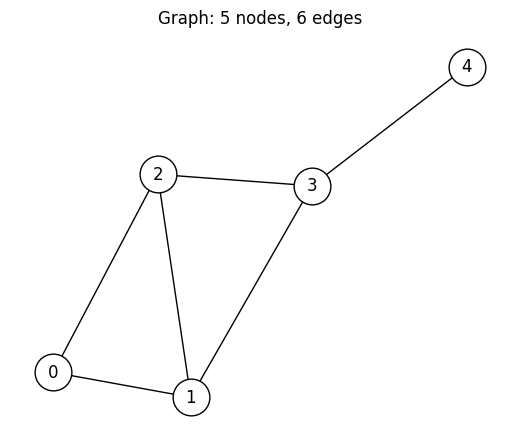

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## QUBO 定式化

QAOA で最小化するために、MaxCut の目的関数を符号反転します:

$$
\min_x \sum_{(i,j) \in E} \bigl(2 x_i x_j - x_i - x_j \bigr)
$$

これは QUBO 辞書に変換でき、各辺 $(i, j)$ の寄与は:

- $Q_{ii} \mathrel{-}= 1$, $Q_{jj} \mathrel{-}= 1$（対角要素）
- $Q_{ij} \mathrel{+}= 2$（非対角要素）

In [3]:
from qamomile.optimization.binary_model import BinaryModel, VarType

# グラフの辺から QUBO 辞書を構築
qubo: dict[tuple[int, int], float] = {}
for i, j in G.edges():
    qubo[(i, i)] = qubo.get((i, i), 0.0) - 1.0
    qubo[(j, j)] = qubo.get((j, j), 0.0) - 1.0
    qubo[(i, j)] = qubo.get((i, j), 0.0) + 2.0

print("QUBO coefficients:")
for key, val in sorted(qubo.items()):
    print(f"  {key}: {val}")

model = BinaryModel.from_qubo(qubo)
print(f"\nNumber of variables: {model.num_bits}")
print(f"Variable type: {model.vartype}")

QUBO coefficients:
  (0, 0): -2.0
  (0, 1): 2.0
  (0, 2): 2.0
  (1, 1): -3.0
  (1, 2): 2.0
  (1, 3): 2.0
  (2, 2): -3.0
  (2, 3): 2.0
  (3, 3): -3.0
  (3, 4): 2.0
  (4, 4): -1.0

Number of variables: 5
Variable type: BINARY


> **Note:** `BinaryModel` は QUBO 以外にも `from_ising()` や `from_hubo()` といったコンストラクタを提供しています。また、`change_vartype()` でバイナリ表現とスピン表現を相互に変換できます。

## QUBO から Ising モデルへ

QAOA はバイナリ変数 ($x_i \in \{0, 1\}$) ではなく、**スピン変数** ($s_i \in \{+1, -1\}$) で動作します。変換式は:

$$
x_i = \frac{1 - s_i}{2}
$$

量子力学の規約 $Z|0\rangle = |0\rangle$, $Z|1\rangle = -|1\rangle$ に対応しており、バイナリ 0 はスピン $+1$、バイナリ 1 はスピン $-1$ に写ります。

QUBO に代入すると Ising ハミルトニアンが得られます:

$$
H = \sum_i h_i \, s_i + \sum_{i < j} J_{ij} \, s_i \, s_j + \text{const}
$$

In [4]:
spin_model = model.change_vartype(VarType.SPIN).normalize_by_abs_max()

print(f"Variable type: {spin_model.vartype}")
print(f"Linear terms (h_i):     {spin_model.linear}")
print(f"Quadratic terms (J_ij): {spin_model.quad}")
print(f"Constant:               {spin_model.constant}")

Variable type: SPIN
Linear terms (h_i):     {}
Quadratic terms (J_ij): {(0, 1): 1.0, (0, 2): 1.0, (1, 2): 1.0, (1, 3): 1.0, (2, 3): 1.0, (3, 4): 1.0}
Constant:               -6.0


## 厳密解（全探索）

QAOA を実行する前に、すべての $2^n = 32$ 通りの分割を試して最適解を求めておきます。QAOA の結果と比較するための基準になります。

In [5]:
import itertools

best_cut = 0
optimal_partitions: list[tuple[int, ...]] = []

for bits in itertools.product([0, 1], repeat=num_nodes):
    cut = sum(1 for i, j in G.edges() if bits[i] != bits[j])
    if cut > best_cut:
        best_cut = cut
        optimal_partitions = [bits]
    elif cut == best_cut:
        optimal_partitions.append(bits)

print(f"Optimal MaxCut value: {best_cut}")
print(f"Number of optimal partitions: {len(optimal_partitions)}")
for part in optimal_partitions:
    print(f"  {part}")

Optimal MaxCut value: 5
Number of optimal partitions: 2
  (0, 1, 1, 0, 1)
  (1, 0, 0, 1, 0)


## QAOA 回路: 基本的な考え方

QAOA のアンザッツはパラメータ付き量子状態を準備します:

$$
|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle
= \prod_{l=1}^{p}
  e^{-i \beta_l H_M} \, e^{-i \gamma_l H_C}
  \; |{+}\rangle^{\otimes n}
$$

ここで:
- $|{+}\rangle^{\otimes n}$: 一様重ね合わせ（全量子ビットに Hadamard ゲート）
- $e^{-i \gamma H_C}$: **コストユニタリ** — Ising コストの場合、$\text{RZZ}$ と $\text{RZ}$ ゲートに分解されます（ゲートの規約についてはステップ 2–3 を参照）
- $e^{-i \beta H_M}$: **ミキサーユニタリ** — $H_M = \sum_i X_i$ の場合、各量子ビットへの $\text{RX}(2\beta)$ になります
- $p$: レイヤー数（アンザッツの深さ）

各コンポーネントを `@qkernel` として実装していきます。

### ステップ 1: 一様重ね合わせ

全量子ビットに Hadamard ゲートを適用し、均等な重ね合わせ状態 $|{+}\rangle^{\otimes n}$ を作ります。

In [6]:
import qamomile.circuit as qmc


@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q

### ステップ 2: コスト層

コストユニタリ $e^{-i \gamma H_C}$ を適用します。

Qamomile の回転ゲートは $1/2$ の因子を含む規約を使います: $\text{RZ}(\theta) = e^{-i \theta Z / 2}$、$\text{RZZ}(\theta) = e^{-i \theta Z \otimes Z / 2}$。$e^{-i \gamma H_C}$ と厳密に一致させるには角度を $2 J_{ij} \gamma$ とすべきですが、$\gamma$ は古典オプティマイザが自由に調整する**変分パラメータ**であるため、この定数倍は最適な $\gamma$ の値に吸収されます。したがって、$J_{ij} \cdot \gamma$（および $h_i \cdot \gamma$）をそのまま渡します:

In [7]:
@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q

### ステップ 3: ミキサー層

ミキサーユニタリ $e^{-i \beta H_M}$ を適用します（$H_M = \sum_i X_i$）。$\text{RX}(\theta) = e^{-i \theta X / 2}$ なので、$e^{-i \beta X_i}$ を実装するには $\theta = 2\beta$ とします。

In [8]:
@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q

### ステップ 4: 完全な QAOA アンザッツ

3 つの要素を組み合わせます: 重ね合わせ → $p$ ラウンドのコスト層 + ミキサー層 → 測定。

In [9]:
@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

## トランスパイルと最適化

カーネルをトランスパイルします。問題の構造（グラフの係数、量子ビット数、レイヤー数）はバインドし、`gammas` と `betas` はオプティマイザがチューニングするランタイムパラメータとして残します。

In [10]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 3  # QAOA レイヤー数

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`scipy.optimize.minimize` の COBYLA 法を使います。各反復で回路をサンプリングし、平均エネルギーを評価します。

In [11]:
import os
import numpy as np
from scipy.optimize import minimize

executor = transpiler.executor()
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 20 if docs_test_mode else 500
cost_history: list[float] = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    result = executable.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    ).result()
    decoded = spin_model.decode_from_sampleresult(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


rng = np.random.default_rng(42)
initial_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)

res = minimize(cost_fn, initial_params, method="COBYLA", options={"maxiter": maxiter})

print(f"Optimized cost: {res.fun:.4f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")

Optimized cost: -8.4326
Optimal params: [np.float64(1.6484), np.float64(-0.9053), np.float64(1.0593), np.float64(0.0106), np.float64(-2.004), np.float64(1.2793)]


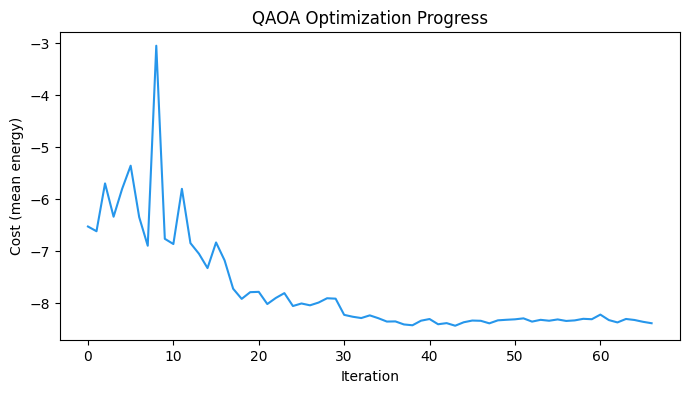

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("QAOA Optimization Progress")
plt.show()

## 結果のデコードと分析

最適化されたパラメータで回路をサンプリングし、測定結果を解釈します。MaxCut ではすべてのビット列が有効な分割なので、実行可能性のチェックは不要です。各サンプルのカット辺数を数えるだけです。

In [13]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

final_result = executable.sample(
    executor,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded = spin_model.decode_from_sampleresult(final_result)

In [14]:
from collections import Counter

cut_distribution: Counter[int] = Counter()
best_qaoa_cut = 0
best_qaoa_sample = None

for sample, energy, occ in zip(
    decoded.samples, decoded.energy, decoded.num_occurrences
):
    # スピン (+1/-1) をバイナリ (0/1) に変換: x = (1 - s) / 2
    binary = {idx: (1 - s) // 2 for idx, s in sample.items()}
    bits = [binary[i] for i in range(num_nodes)]
    cut = sum(1 for i, j in G.edges() if bits[i] != bits[j])
    cut_distribution[cut] += occ
    if cut > best_qaoa_cut:
        best_qaoa_cut = cut
        best_qaoa_sample = bits

print(f"Best QAOA cut: {best_qaoa_cut}  (optimal: {best_cut})")
print(f"Best partition: {best_qaoa_sample}")

Best QAOA cut: 5  (optimal: 5)
Best partition: [0, 1, 1, 0, 1]


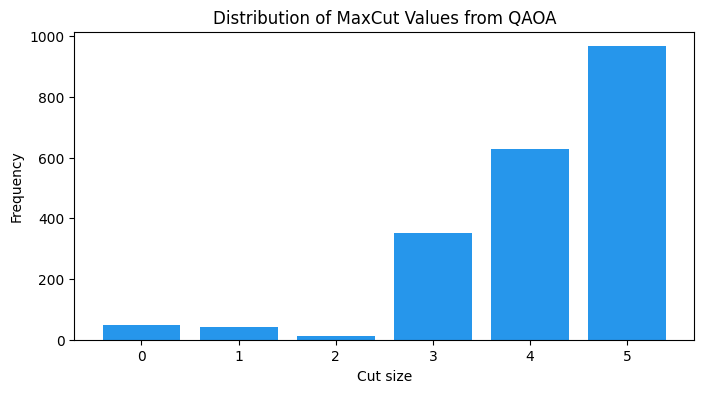

In [15]:
cuts = sorted(cut_distribution.keys())
counts = [cut_distribution[c] for c in cuts]

plt.figure(figsize=(8, 4))
plt.bar([str(c) for c in cuts], counts, color="#2696EB")
plt.xlabel("Cut size")
plt.ylabel("Frequency")
plt.title("Distribution of MaxCut Values from QAOA")
plt.show()

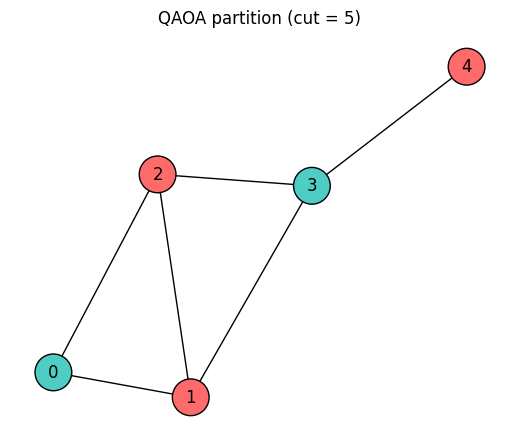

In [16]:
if best_qaoa_sample is not None:
    color_map = [
        "#FF6B6B" if best_qaoa_sample[i] == 1 else "#4ECDC4" for i in range(num_nodes)
    ]
    plt.figure(figsize=(5, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=700,
        edgecolors="black",
    )
    plt.title(f"QAOA partition (cut = {best_qaoa_cut})")
    plt.show()

## 組み込みの `qaoa_state` を使う

上で実装したすべて — 重ね合わせ、コスト層、ミキサー層、レイヤーのループ — は `qamomile.circuit.algorithm.qaoa_state` として既に提供されています。同じ Ising 係数 (`quad`, `linear`) と変分パラメータ (`gammas`, `betas`) を受け取ります。

組み込み関数を使って同じ構造の回路が実装されていることを確認します。環境依存を避けるため、ここでも既定のローカル executor を使います。

In [17]:
from qamomile.circuit.algorithm import qaoa_state


@qmc.qkernel
def qaoa_builtin(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)

同じ最適化済みパラメータでトランスパイル・サンプリングします。

In [18]:
exe_builtin = transpiler.transpile(
    qaoa_builtin,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

executor_manual = transpiler.executor()
executor_builtin = transpiler.executor()

result_manual = executable.sample(
    executor_manual,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

result_builtin = exe_builtin.sample(
    executor_builtin,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded_manual = spin_model.decode_from_sampleresult(result_manual)
decoded_builtin = spin_model.decode_from_sampleresult(result_builtin)
print(f"Manual   mean energy: {decoded_manual.energy_mean():.4f}")
print(f"Built-in mean energy: {decoded_builtin.energy_mean():.4f}")

Manual   mean energy: -8.3125
Built-in mean energy: -8.3193


## まとめ

このチュートリアルでは:

1. MaxCut 問題を定義し、NetworkX グラフから QUBO を構築しました。
2. `BinaryModel` を使って QUBO を Ising モデルに変換しました。
3. QAOA 回路の全コンポーネント — 重ね合わせ、コスト層、ミキサー層、完全なアンザッツ — を `@qkernel` として実装しました。
4. 古典最適化ループを実行し、結果をデコードしました。
5. `qamomile.circuit.algorithm.qaoa_state` が同じ回路を 1 つの関数呼び出しで提供することを確認しました。

**次のステップ:**

- **制約付き最適化**問題（ペナルティ項が必要な場合）については、JijModeling と高レベルの `QAOAConverter` を使う [QAOA によるグラフ分割](../optimization/qaoa_graph_partition) を参照してください。